## **ĐỒ ÁN 3: ABLATION STUDY**
**Mục tiêu:** Kiểm tra sự thay đổi của thuật toán Spectral Clustering khi thay thế/sửa đổi các thành phần cốt lõi, từ đó chứng minh tính hợp lý trong thiết kế của bài báo gốc.

In [16]:
import sys
import networkx as nx
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans

sys.path.append('..')
from src.utils import load_and_preprocess_graph, apply_edge_flipping, get_label_array
from src.model import spectral_clustering
from src.metrics import symmetric_difference_distance, calculate_all_metrics

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

print("Đang tải dữ liệu và tính mốc chuẩn (Baseline)...")
G_clean = load_and_preprocess_graph('../data/0.edges')
clean_c1, clean_c2, _ = spectral_clustering(G_clean)
all_nodes = list(G_clean.nodes())
y_true = get_label_array(all_nodes, clean_c1, clean_c2)
print("Tải dữ liệu hoàn tất!")

Đang tải dữ liệu và tính mốc chuẩn (Baseline)...
Tải dữ liệu hoàn tất!


### **PHẦN 1: THAY ĐỔI THÀNH PHẦN THUẬT TOÁN**
* **Giả thuyết 1:** Ma trận `Normalized Laplacian` sẽ chống nhiễu LDP (Hub nodes) tốt hơn `Unnormalized Laplacian` (Baseline).
* **Giả thuyết 2:** Phương pháp `Sweep-Cut` bám sát cấu trúc đồ thị nên sẽ bền vững hơn thuật toán `K-Means`.

In [17]:
# ABLATION 1: Dùng Normalized Laplacian
def ablation_normalized_laplacian(G):
    L = nx.normalized_laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v2 = np.real(eigenvectors[:, 1]) 
    
    node_scores = [(node, v2[i]) for i, node in enumerate(G.nodes())]
    sorted_nodes = [node for node, score in sorted(node_scores, key=lambda x: x[1])]
    
    best_ratio = float('inf')
    best_c1, best_c2 = [], []
    for i in range(1, len(sorted_nodes)):
        S1, S2 = sorted_nodes[:i], sorted_nodes[i:]
        ratio = nx.cut_size(G, S1, S2) / (len(S1) * len(S2))
        if ratio < best_ratio:
            best_ratio = ratio
            best_c1, best_c2 = S1, S2
    return set(best_c1), set(best_c2)

# ABLATION 2: Dùng K-Means thay cho Sweep-Cut
def ablation_kmeans(G):
    L = nx.laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v2 = np.real(eigenvectors[:, 1]) 
    
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(v2.reshape(-1, 1))
    
    nodes = list(G.nodes())
    c1 = [nodes[i] for i in range(len(nodes)) if labels[i] == 0]
    c2 = [nodes[i] for i in range(len(nodes)) if labels[i] == 1]
    return set(c1), set(c2)

In [18]:
probabilities = [i * 0.005 for i in range(1, 40)] # p từ 0.005 đến 0.2
num_trials = 100 

results_p1 = {
    'baseline': {'d_size': [], 'acc': [], 'nmi': [], 'ari': []},
    'normalized': {'d_size': [], 'acc': [], 'nmi': [], 'ari': []},
    'kmeans': {'d_size': [], 'acc': [], 'nmi': [], 'ari': []}
}

print("Đang chạy Thực nghiệm Phần 1...")
for p in tqdm(probabilities):
    temp = {k: {'d_size': [], 'acc': [], 'nmi': [], 'ari': []} for k in results_p1.keys()}
    
    for trial in range(num_trials):
        G_noisy = apply_edge_flipping(G_clean, p=p, seed=GLOBAL_SEED + trial)
        
        # Chạy 3 model
        models = {
            'baseline': spectral_clustering(G_noisy)[:2],
            'normalized': ablation_normalized_laplacian(G_noisy),
            'kmeans': ablation_kmeans(G_noisy)
        }
        
        for name, (c1, c2) in models.items():
            y_pred = get_label_array(all_nodes, c1, c2)
            metrics = calculate_all_metrics(y_true, y_pred)
            temp[name]['d_size'].append(symmetric_difference_distance(clean_c1, clean_c2, c1, c2))
            temp[name]['acc'].append(metrics['ACC'])
            temp[name]['nmi'].append(metrics['NMI'])
            temp[name]['ari'].append(metrics['ARI'])

    # Lưu Worst-case cho d_size, Average cho ACC, NMI, ARI
    for name in results_p1.keys():
        results_p1[name]['d_size'].append(np.max(temp[name]['d_size']))
        results_p1[name]['acc'].append(np.mean(temp[name]['acc']))
        results_p1[name]['nmi'].append(np.mean(temp[name]['nmi']))
        results_p1[name]['ari'].append(np.mean(temp[name]['ari']))

Đang chạy Thực nghiệm Phần 1...


100%|██████████| 39/39 [16:40<00:00, 25.65s/it]


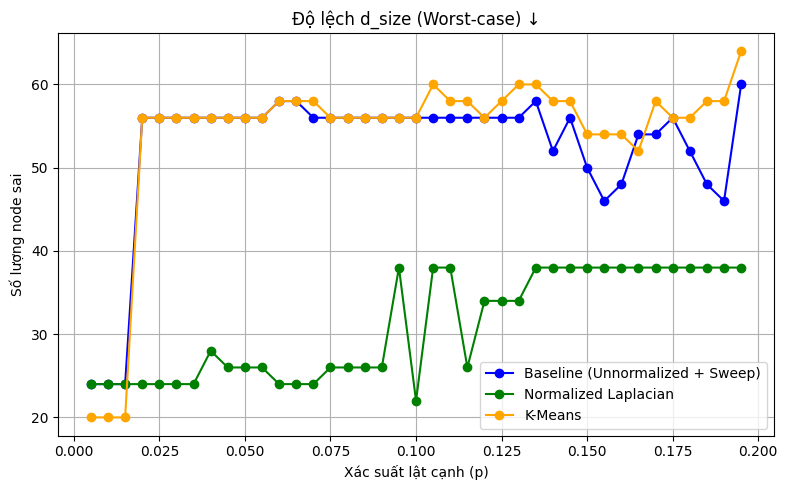

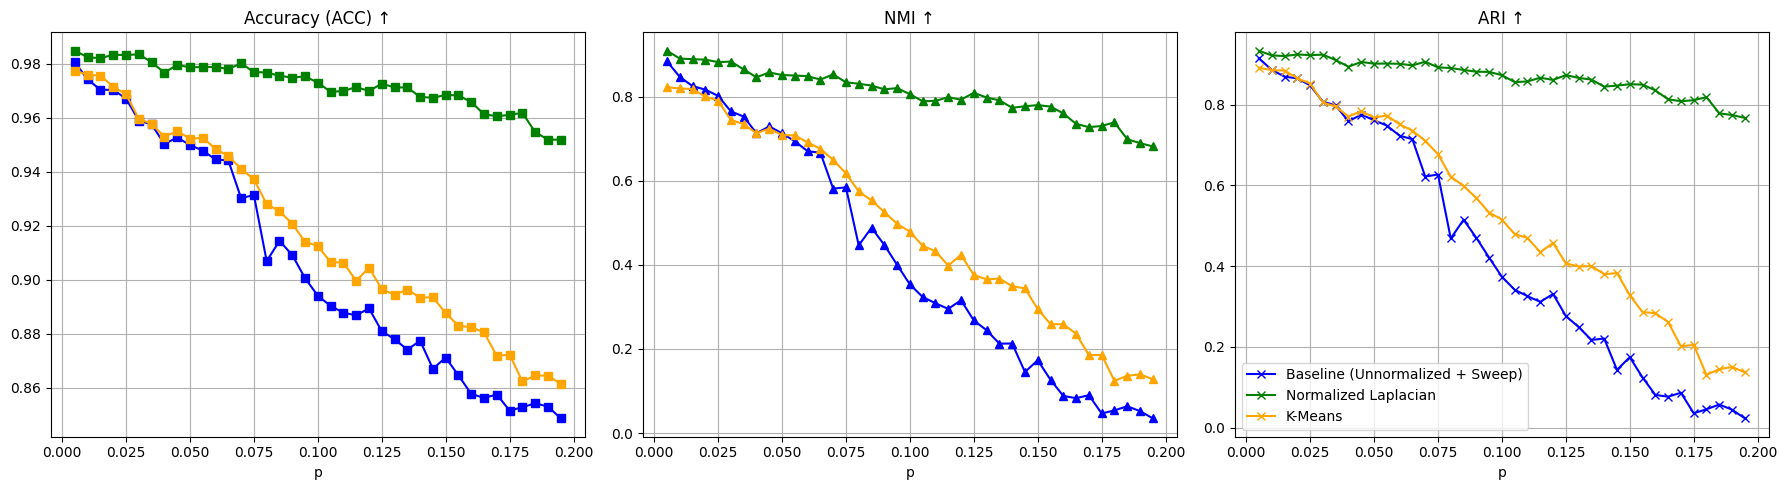

In [ ]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
for m in results_p1.keys():
    ax1.plot(probabilities, results_p1[m]['d_size'], marker='o', label=labels[m], color=colors[m])
ax1.set_title('Độ lệch d_size (Worst-case) ↓')
ax1.set_xlabel('Xác suất lật cạnh (p)')
ax1.set_ylabel('Số lượng node sai')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
# plt.savefig('ablation_dsize.pdf', format='pdf')
plt.show()

fig2, axs = plt.subplots(1, 3, figsize=(18, 5))
# Accuracy
for m in results_p1.keys():
    axs[0].plot(probabilities, results_p1[m]['acc'], marker='s', label=labels[m], color=colors[m])
axs[0].set_title('Accuracy (ACC) ↑')
axs[0].set_xlabel('p')
axs[0].grid(True)
# NMI
for m in results_p1.keys():
    axs[1].plot(probabilities, results_p1[m]['nmi'], marker='^', label=labels[m], color=colors[m])
axs[1].set_title('NMI ↑')
axs[1].set_xlabel('p')
axs[1].grid(True)
# ARI
for m in results_p1.keys():
    axs[2].plot(probabilities, results_p1[m]['ari'], marker='x', label=labels[m], color=colors[m])
axs[2].set_title('ARI ↑')
axs[2].set_xlabel('p')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
# plt.savefig('ablation_metrics.pdf', format='pdf')
plt.show()

### **PHẦN 2: LỰA CHỌN VECTOR RIÊNG (v2 vs v3 vs v4)**
* **Giả thuyết:** Lý thuyết phổ đồ thị chỉ ra duy nhất vector riêng thứ 2 (Fiedler vector) có thể chia đồ thị làm 2 phần. Việc chọn sai vector (v3, v4) sẽ làm thuật toán thất bại ngay cả khi đồ thị chưa bị nhiễu.

Đang chạy Thực nghiệm Phần 2 (50 lần lặp)...


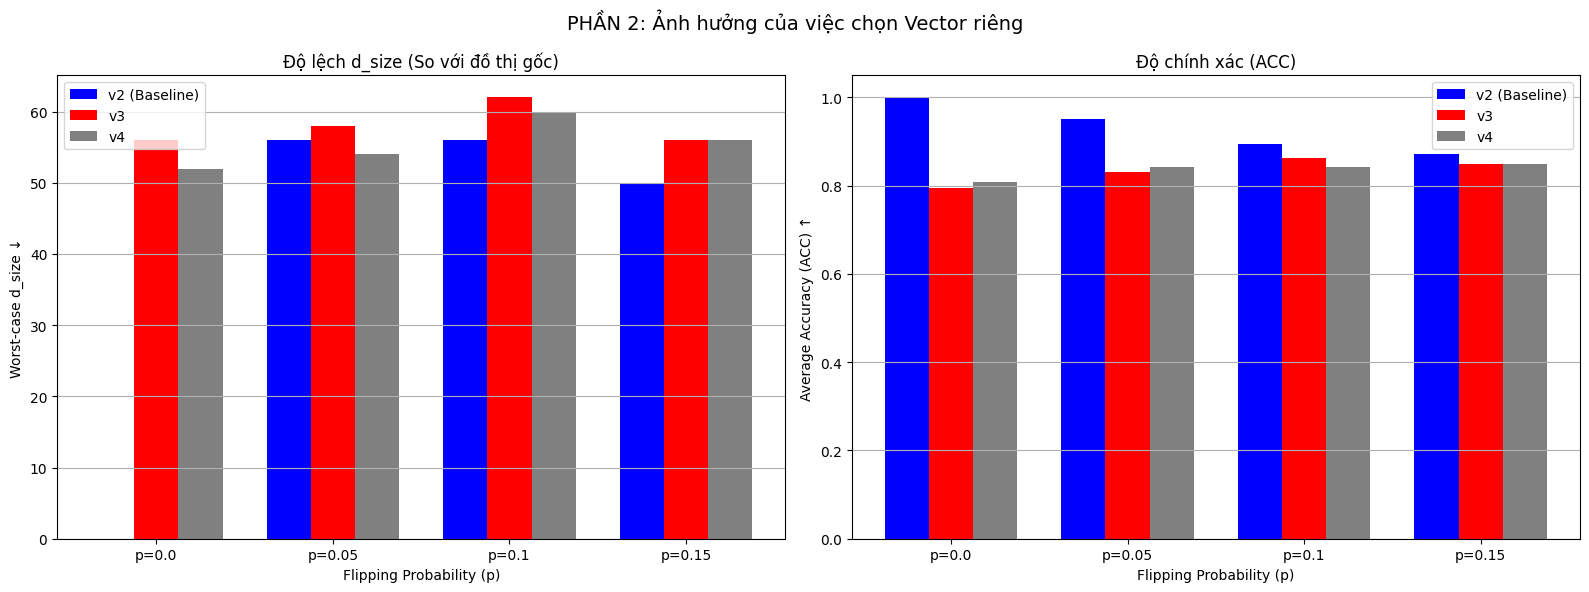

In [ ]:
def ablation_custom_eigenvector(G, vector_index):
    L = nx.laplacian_matrix(G).toarray().astype(float)
    _, eigenvectors = scipy.linalg.eigh(L)
    v_custom = np.real(eigenvectors[:, vector_index]) 
    
    node_scores = [(node, v_custom[i]) for i, node in enumerate(G.nodes())]
    sorted_nodes = [node for node, score in sorted(node_scores, key=lambda x: x[1])]
    
    best_ratio = float('inf')
    best_c1, best_c2 = [], []
    for i in range(1, len(sorted_nodes)):
        S1, S2 = sorted_nodes[:i], sorted_nodes[i:]
        ratio = nx.cut_size(G, S1, S2) / (len(S1) * len(S2))
        if ratio < best_ratio:
            best_ratio = ratio
            best_c1, best_c2 = S1, S2
    return set(best_c1), set(best_c2)

p_test = [0.0, 0.05, 0.1, 0.15]
num_trials_p2 = 100  
vectors = {'v2 (Baseline)': 1, 'v3 (Ablation)': 2, 'v4 (Ablation)': 3}

results_p2 = {name: {'acc': [], 'd_size': []} for name in vectors.keys()}

for p in p_test:
    temp_p2 = {name: {'acc': [], 'd_size': []} for name in vectors.keys()}
    
    for trial in range(num_trials_p2):
        G_noisy = apply_edge_flipping(G_clean, p=p, seed=GLOBAL_SEED + trial)
        
        for name, idx in vectors.items():
            c1, c2 = ablation_custom_eigenvector(G_noisy, idx)
            y_pred = get_label_array(all_nodes, c1, c2)
            
            metrics = calculate_all_metrics(y_true, y_pred)
            d_size = symmetric_difference_distance(clean_c1, clean_c2, c1, c2)
            
            temp_p2[name]['acc'].append(metrics['ACC'])
            temp_p2[name]['d_size'].append(d_size)
            
    for name in vectors.keys():
        results_p2[name]['acc'].append(np.mean(temp_p2[name]['acc']))
        results_p2[name]['d_size'].append(np.max(temp_p2[name]['d_size']))

x = np.arange(len(p_test))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PHẦN 2: Ảnh hưởng của việc chọn Vector riêng', fontsize=14)

ax1.bar(x - width, results_p2['v2 (Baseline)']['d_size'], width, label='v2 (Baseline)', color='blue')
ax1.bar(x, results_p2['v3 (Ablation)']['d_size'], width, label='v3', color='red')
ax1.bar(x + width, results_p2['v4 (Ablation)']['d_size'], width, label='v4', color='grey')
ax1.set_ylabel('Worst-case d_size ↓')
ax1.set_xlabel('Flipping Probability (p)')
ax1.set_title('Độ lệch d_size (So với đồ thị gốc)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"p={p}" for p in p_test])
ax1.legend()
ax1.grid(axis='y')

ax2.bar(x - width, results_p2['v2 (Baseline)']['acc'], width, label='v2 (Baseline)', color='blue')
ax2.bar(x, results_p2['v3 (Ablation)']['acc'], width, label='v3', color='red')
ax2.bar(x + width, results_p2['v4 (Ablation)']['acc'], width, label='v4', color='grey')
ax2.set_ylabel('Average Accuracy (ACC) ↑')
ax2.set_xlabel('Flipping Probability (p)')
ax2.set_title('Độ chính xác (ACC)')
ax2.set_xticks(x)
ax2.set_xticklabels([f"p={p}" for p in p_test])
ax2.legend()
ax2.grid(axis='y')

plt.tight_layout()
# plt.savefig('eigenvector_ablation.pdf', format='pdf') 
plt.show()